# Статистика, DS-поток
## Марафон-домашка SM.12, практическая часть

**Правила:**

* Дедлайны см. в боте. После дедлайна работы не принимаются кроме случаев наличия уважительной причины.
* Прислать нужно **ноутбук в формате `ipynb`**.
* Следите за размером файлов. **Бот не может принимать файлы весом более 20 Мб.** Если файл получается больше, заранее разделите его на несколько.
* Выполнять задание необходимо полностью самостоятельно. **При обнаружении списывания все участники списывания будут сдавать устный зачет.**
* Решения, размещенные на каких-либо интернет-ресурсах, не принимаются. Кроме того, публикация решения в открытом доступе может быть приравнена к предоставлении возможности списать.
* Для выполнения задания используйте этот ноутбук в качестве основы, **не исправляйте и не удаляйте условия!** Можно добавлять необходимое количество ячеек.
* Комментарии к решению пишите в markdown-ячейках.
* Выполнение задания (ход решения, выводы и пр.) должно быть осуществлено на русском языке.
* Решение проверяется системой ИИ-проверки <a href="https://thetahat.ru/"><img src="https://miptstats.github.io/theta_grader_small.png" style="display: inline; vertical-align: middle;"></a> **ThetaGrader**. Результат проверки валидируется и исправляется человеком, после чего комментарии отправляются студентам.
* Если код будет не понятен проверяющему, оценка может быть снижена.
* Никакой код из данного задания при проверке запускаться не будет. *Если код студента не выполнен, недописан и т.д., то он не оценивается.*
* В каждой задаче не забывайте делать **пояснения и выводы**.

**Правила оформления теоретических задач:**

* Решения необходимо прислать в виде $\LaTeX$ в markdown-ячейках.
* В решениях поясняйте, чем вы пользуетесь, хотя бы кратко. Например, если пользуетесь независимостью, то достаточно подписи вида "*X и Y незав.*"
* Решение, в котором есть только ответ, и отсутствуют вычисления, оценивается в 0 баллов.

**Баллы за задание:**

* Задача 1 &mdash;  120 баллов



In [ ]:
# Bot check

# HW_ID: ds_sm11
# Бот проверит этот ID и предупредит, если случайно сдать что-то не то.

# Status: not final
# Перед отправкой в финальном решении удали "not" в строчке выше.
# Так бот проверит, что ты отправляешь финальную версию, а не промежуточную.
# Никакие значения в этой ячейке не влияют на факт сдачи работы.

In [54]:
import numpy as np
import scipy.stats as sps
import matplotlib.pyplot as plt
import seaborn as sns

from tqdm.notebook import tqdm

sns.set(style="darkgrid", font_scale=1.3, palette=['#7570b3','#e7298a','#66a61e','#1b9e77','#e6ab02','#d95f02'])

### Ссылки на использование ИИ

Если при решении задач использовался ИИ, укажи здесь публичные ссылки на все чаты с ИИ и поясни, для каких целей он применялся. Обрати внимание на <a href="https://thetahat.ru/courses/ai-rules" target="_top">правила</a>.

**Задача 1**
1. ссылка
    - для чего использована
    - для чего использована
2. ссылка
    - для чего использована

**Задача 2**
1. ссылка
    - для чего использована

---
### Задача 1

В этой задаче исследуем свойства функций правдоподобия и поймем смысл понятий вклада и информации Фишера.

**1.** Рассмотрим выборку $X = (X_1, ..., X_n)$ из распределения Бернулли с параметром $\theta \in (0, 1)$. Проведите исследование в этой задаче для выборок размера 50 и следующих значений параметра: $0.5, 0.7, 0.85, 0.95$.

Для каждого значения параметра сгенерируйте выборку размера 50 и постройте графики
* функции правдоподобия,
* логарифмической функции правдподобия,
* вклада выборки в оценку параметра,
* второй производной логарифмической функции правдподобия.

*Указания*
* Стройте графики компактно в виде таблицы: столбцы таблицы &mdash; различные истинные значения параметра, а по строкам &mdash; разные функции. 
* На графиках отметьте истинное значение параметра вертикальной линией.
* Для отрисовки графиков используйте достаточно подробную сетку значений.
* Масштаб всех осей для разных истинных значений параметра (т.е. для графиков по строке) должен быть одинаковым.

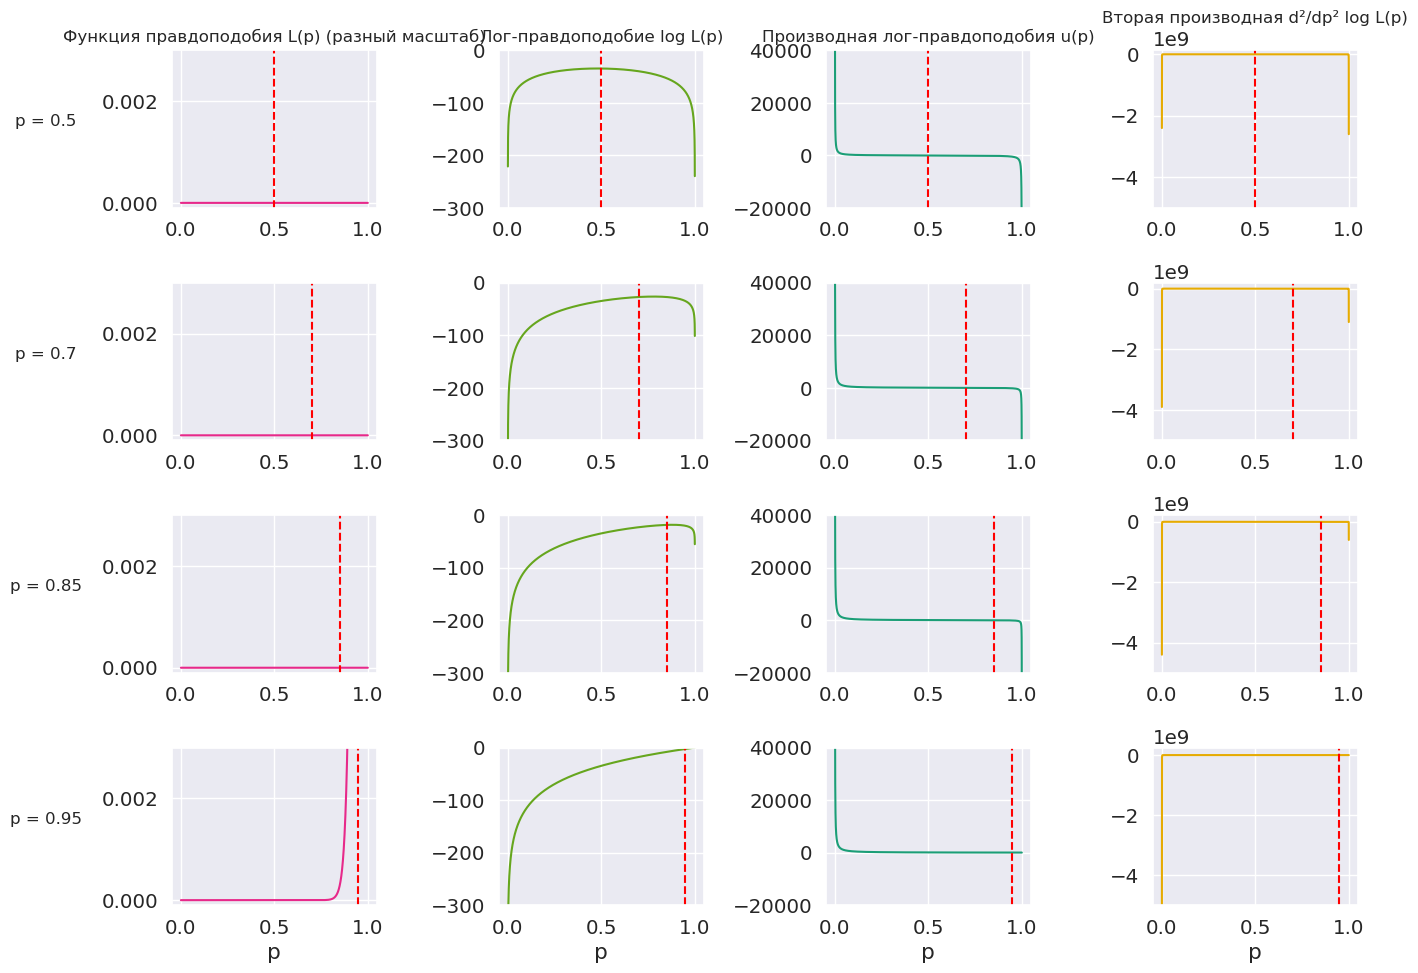

In [80]:
theta_grid = [0.5, 0.7, 0.85, 0.95]
p = np.linspace(0, 1, 10000)[1: -1]
n = 50

fig, axes = plt.subplots(
    nrows=len(theta_grid),
    ncols=4,
    figsize=(14, 10),
)

col_names = [
    "Функция правдоподобия L(p)",
    "Лог-правдоподобие log L(p)",
    "Производная лог-правдоподобия u(p)",
    "Вторая производная d²/dp² log L(p)"
]

for j, name in enumerate(col_names):
    axes[0, j].set_title(name, fontsize=12)

for i, theta in enumerate(theta_grid):
    axes[i, 0].set_ylabel(f"p = {theta}", fontsize=12, rotation=0, labelpad=40)

    x = sps.bernoulli(theta).rvs(n)
    s = np.sum(x)

    L  = p ** s * (1 - p) ** (n - s)
    l  = s * np.log(p) + (n - s) * np.log(1 - p)
    u  = s / p - (n - s) / (1 - p)
    du = -s / p ** 2 - (n - s) / (1 - p) ** 2

    axes[i, 0].plot(p, L, color='C1')
    axes[i, 0].axvline(theta, linestyle='--', color='r')
    axes[i, 0].set_ylim(-0.1e-3, 3e-3)
    axes[i, 1].plot(p, l, color='C2')
    axes[i, 1].axvline(theta, linestyle='--', color='r')
    axes[i, 1].set_ylim(-300, 0)
    axes[i, 2].plot(p, u, color='C3')
    axes[i, 2].axvline(theta, linestyle='--', color='r')
    axes[i, 2].set_ylim(-2e4, 4e4)
    axes[i, 3].plot(p, du, color='C4')
    axes[i, 3].axvline(theta, linestyle='--', color='r')
    axes[i, 3].set_ylim(-5e9)
    

for ax in axes[-1]:
    ax.set_xlabel("p")

plt.tight_layout()
plt.show()



Повторите эксперимент $K$ раз (не менее 200) и нарисуйте на каждом графике по $K$ функций, установив параметр прозрачности.

0it [00:00, ?it/s]

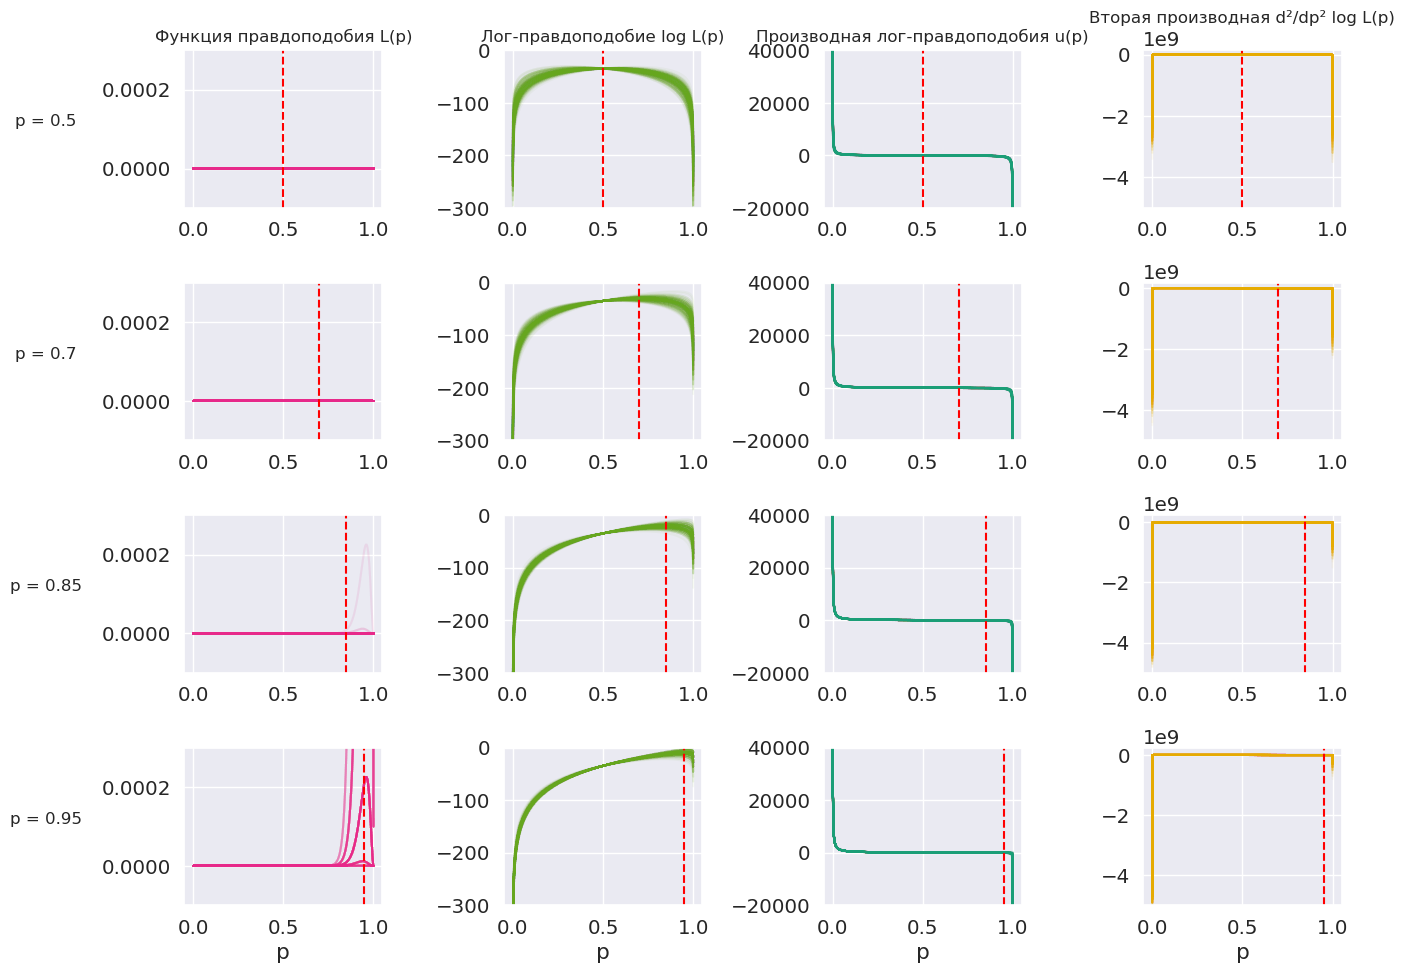

In [112]:
theta_grid = [0.5, 0.7, 0.85, 0.95]
p = np.linspace(0, 1, 10000)[1: -1]
n = 50
k = 200

fig, axes = plt.subplots(
    nrows=len(theta_grid),
    ncols=4,
    figsize=(14, 10),
)

col_names = [
    "Функция правдоподобия L(p)",
    "Лог-правдоподобие log L(p)",
    "Производная лог-правдоподобия u(p)",
    "Вторая производная d²/dp² log L(p)"
]

for j, name in enumerate(col_names):
    axes[0, j].set_title(name, fontsize=12)

for i, theta in tqdm(enumerate(theta_grid)):
    for j in range(k):
        axes[i, 0].set_ylabel(f"p = {theta}", fontsize=12, rotation=0, labelpad=40)
    
        x = sps.bernoulli(theta).rvs(n)
        s = np.sum(x)
    
        L  = p ** s * (1 - p) ** (n - s)
        l  = s * np.log(p) + (n - s) * np.log(1 - p)
        u  = s / p - (n - s) / (1 - p)
        du = -s / p ** 2 - (n - s) / (1 - p) ** 2

        axes[i, 0].set_ylim(-0.1e-3, 3e-4)
        axes[i, 0].plot(p, L, color='C1', alpha = 0.05)

        axes[i, 1].set_ylim(-300, 0)
        axes[i, 1].plot(p, l, color='C2', alpha = 0.05)

        axes[i, 1].set_ylim(-300, 0)
        axes[i, 2].plot(p, u, color='C3', alpha = 0.05)

        axes[i, 2].set_ylim(-2e4, 4e4)
        axes[i, 3].plot(p, du, color='C4', alpha = 0.05)

        axes[i, 3].set_ylim(-5e9)

for i, theta in enumerate(theta_grid):
    axes[i, 0].axvline(theta, linestyle='--', color='r')
    axes[i, 1].axvline(theta, linestyle='--', color='r')  
    axes[i, 2].axvline(theta, linestyle='--', color='r')
    axes[i, 3].axvline(theta, linestyle='--', color='r')

for ax in axes[-1]:
    ax.set_xlabel("p")

plt.tight_layout()
plt.show()

Кажется, все особенности не позволяет разглядеть масштаб графиков. Ограничьте значения по горизонтальной оси как $[\theta_0 - \varepsilon, \theta_0 + \varepsilon]$, где $\varepsilon = 0.05$. При этом сохраняйте одинаковый масштаб осей.

0it [00:00, ?it/s]

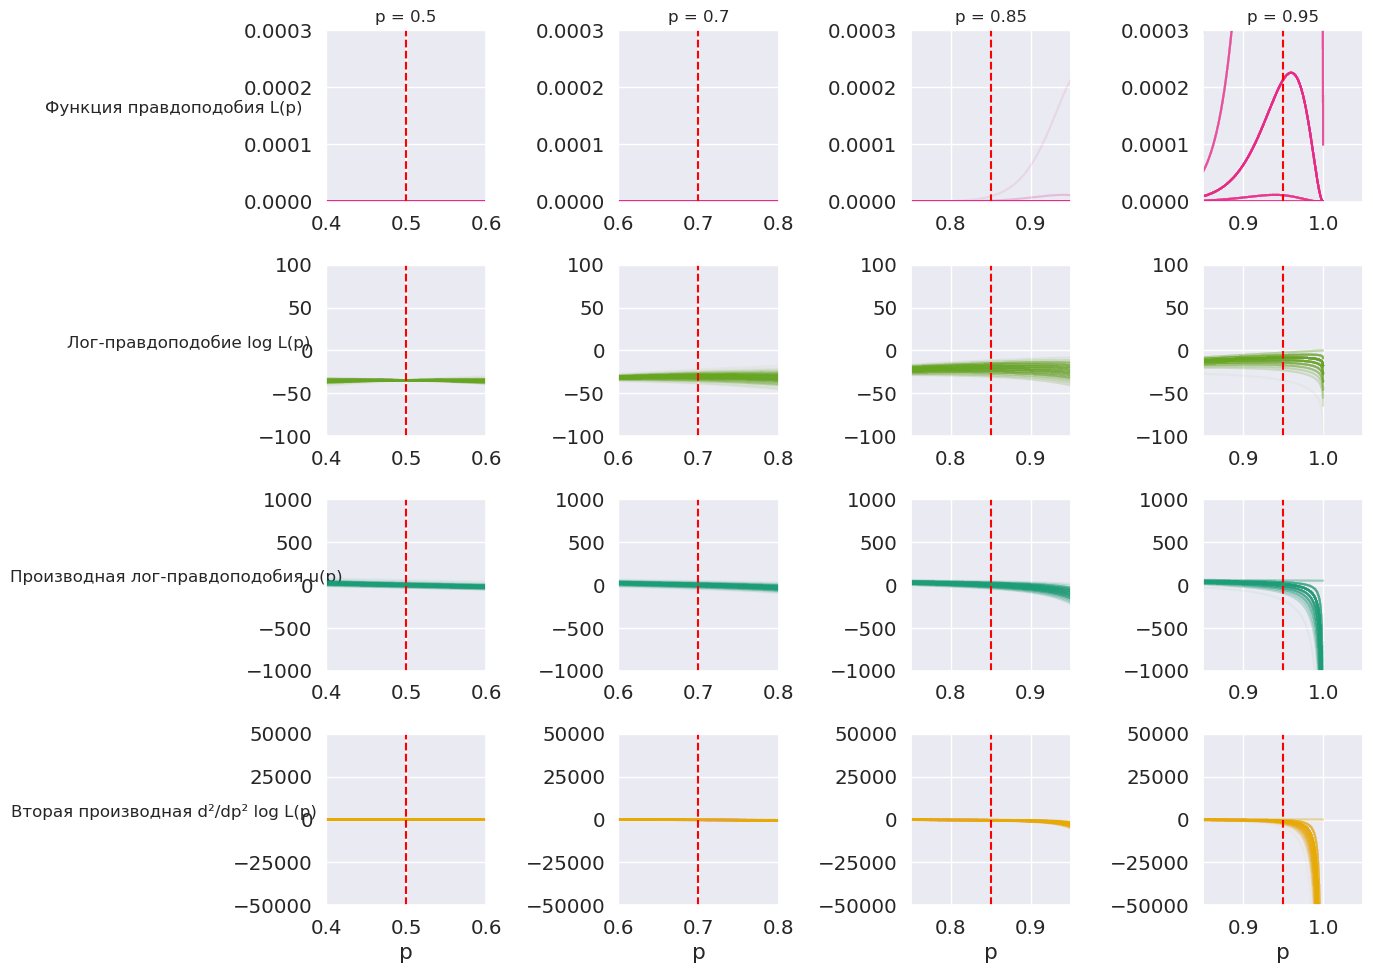

In [111]:
theta_grid = [0.5, 0.7, 0.85, 0.95]
p = np.linspace(0, 1, 10000)[1: -1]
n = 50
k = 200

fig, axes = plt.subplots(
    nrows=4,
    ncols=len(theta_grid),
    figsize=(14, 10),
)

row_names = [
    "Функция правдоподобия L(p)",
    "Лог-правдоподобие log L(p)",
    "Производная лог-правдоподобия u(p)",
    "Вторая производная d²/dp² log L(p)"
]

for j, theta in enumerate(theta_grid):
    axes[0, j].set_title(f"p = {theta}", fontsize=12)

for i, name in enumerate(row_names):
    axes[i, 0].set_ylabel(name, fontsize=12, rotation=0, labelpad=50)

for j, theta in tqdm(enumerate(theta_grid)):
    for t in range(k):

        x = sps.bernoulli(theta).rvs(n)
        s = np.sum(x)

        L  = p ** s * (1 - p) ** (n - s)
        l  = s * np.log(p) + (n - s) * np.log(1 - p)
        u  = s / p - (n - s) / (1 - p)
        du = -s / p ** 2 - (n - s) / (1 - p) ** 2

        axes[0, j].set_ylim(-0.1e-10, 3e-4)
        axes[0, j].plot(p, L, color='C1', alpha=0.05)

        axes[1, j].set_ylim(-100, 100)
        axes[1, j].plot(p, l, color='C2', alpha=0.05)

        axes[2, j].set_ylim(-1e3, 1e3)
        axes[2, j].plot(p, u, color='C3', alpha=0.05)

        axes[3, j].set_ylim(-5e4, 5e4)
        axes[3, j].plot(p, du, color='C4', alpha=0.05)

    delta = 0.1
    x0 = theta - delta
    x1 = theta + delta
    for i in range(4):
        axes[i, j].set_xlim(x0, x1)

    for i in range(4):
        axes[i, j].axvline(theta, linestyle='--', color='r')

for ax in axes[-1]:
    ax.set_xlabel("p")

plt.tight_layout()
plt.show()


Какие выводы можно сделать
* о среднем и дисперсии вклада в точке истинного значения параметра,
* о среднем значении второй производной логарифмической функции правдподобия в точке истинного значения параметра,
* а также об остроте пика функции правдоподобия?

* Среднее вклада 0 с небольшим отклонением в соотвествующую сторону для всех значений, кроме 0 и 1, в том числе и для наших истинных параметров. Дисперсия увеличивается с ростом параметра. То есть с ростом параметра вклад постепенно перестаёт быть нулевым при значениях, близких к 0 или 1, а его дисперсия растёт
* Аналогично как с вкладом, только дисперсия ещё меньше
* Острота пика увеличивается с ростом параметра

Увеличьте выборку в два раза и нарисуйте те же графики

0it [00:00, ?it/s]

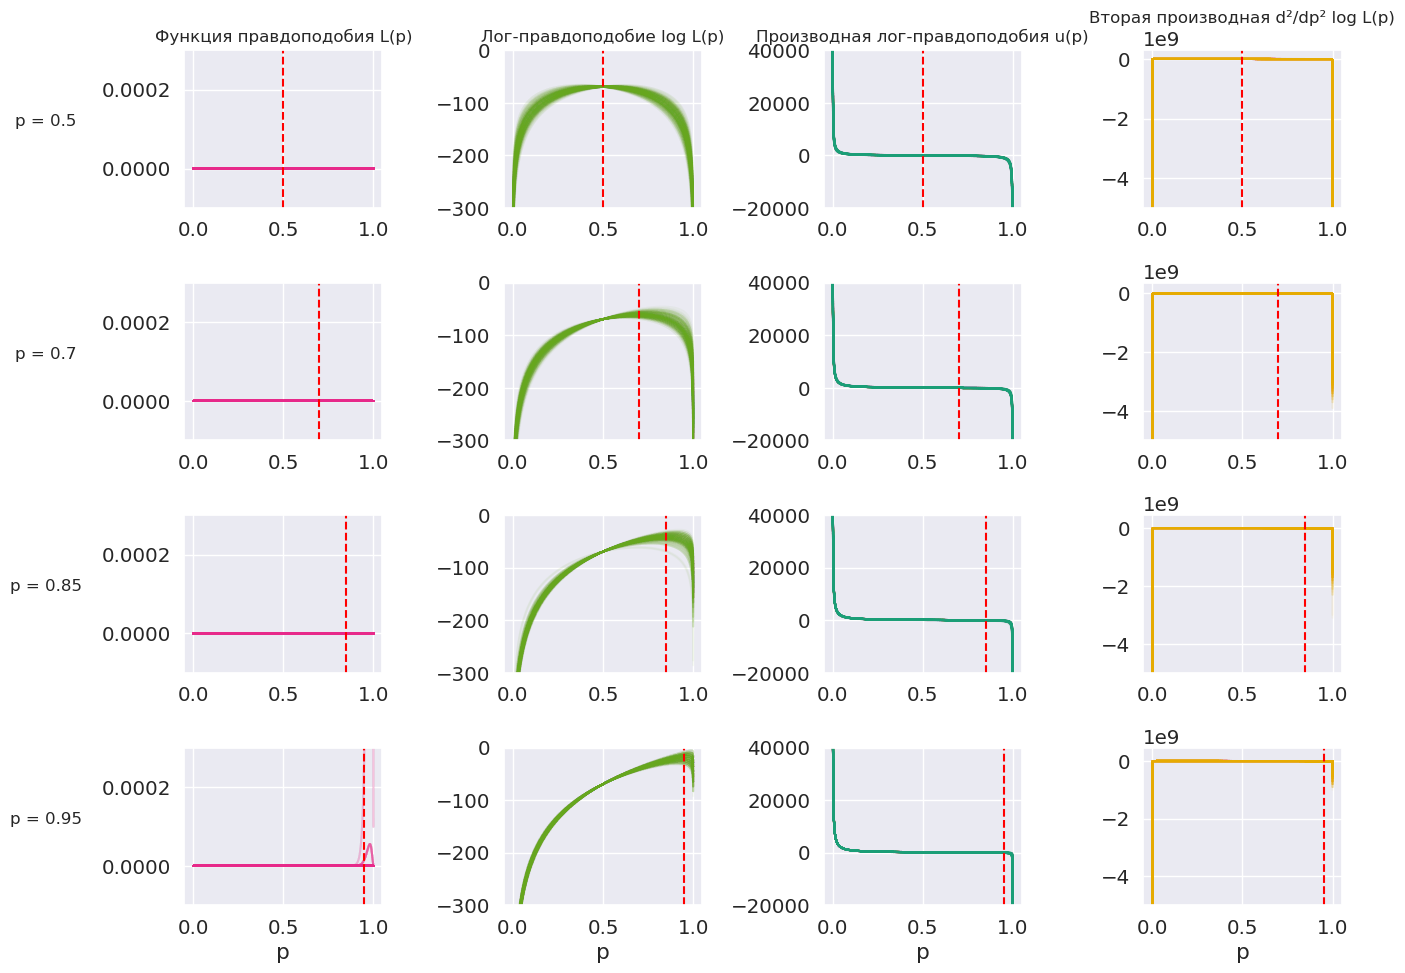

In [118]:
theta_grid = [0.5, 0.7, 0.85, 0.95]
p = np.linspace(0, 1, 10000)[1: -1]
n = 100
k = 200

fig, axes = plt.subplots(
    nrows=len(theta_grid),
    ncols=4,
    figsize=(14, 10),
)

col_names = [
    "Функция правдоподобия L(p)",
    "Лог-правдоподобие log L(p)",
    "Производная лог-правдоподобия u(p)",
    "Вторая производная d²/dp² log L(p)"
]

for j, name in enumerate(col_names):
    axes[0, j].set_title(name, fontsize=12)

for i, theta in tqdm(enumerate(theta_grid)):
    for j in range(k):
        axes[i, 0].set_ylabel(f"p = {theta}", fontsize=12, rotation=0, labelpad=40)
    
        x = sps.bernoulli(theta).rvs(n)
        s = np.sum(x)
    
        L  = p ** s * (1 - p) ** (n - s)
        l  = s * np.log(p) + (n - s) * np.log(1 - p)
        u  = s / p - (n - s) / (1 - p)
        du = -s / p ** 2 - (n - s) / (1 - p) ** 2

        axes[i, 0].set_ylim(-0.1e-3, 3e-4)
        axes[i, 0].plot(p, L, color='C1', alpha = 0.05)

        axes[i, 1].set_ylim(-300, 0)
        axes[i, 1].plot(p, l, color='C2', alpha = 0.05)

        axes[i, 1].set_ylim(-300, 0)
        axes[i, 2].plot(p, u, color='C3', alpha = 0.05)

        axes[i, 2].set_ylim(-2e4, 4e4)
        axes[i, 3].plot(p, du, color='C4', alpha = 0.05)

        axes[i, 3].set_ylim(-5e9)

for i, theta in enumerate(theta_grid):
    axes[i, 0].axvline(theta, linestyle='--', color='r')
    axes[i, 1].axvline(theta, linestyle='--', color='r')  
    axes[i, 2].axvline(theta, linestyle='--', color='r')
    axes[i, 3].axvline(theta, linestyle='--', color='r')

for ax in axes[-1]:
    ax.set_xlabel("p")

plt.tight_layout()
plt.show()

Что изменилось?

Увеличилась дисперсия, изменения с ростом параметра стали более резкие

Постройте график информации Фишера по теоретической формуле

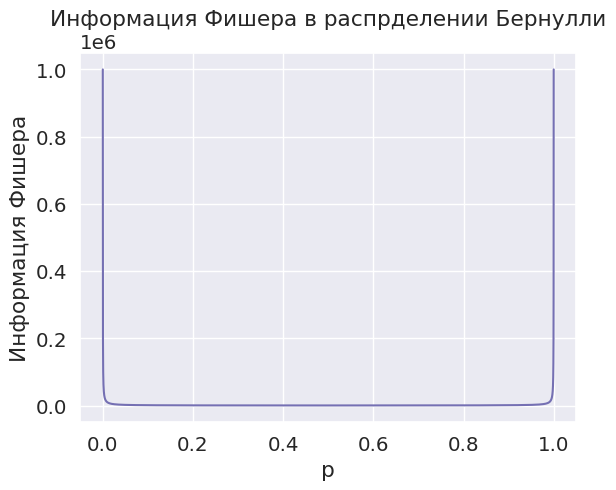

In [122]:
p = np.linspace(0, 1, 10000)[1: -1]
n = 100
I = n / (p * (1 - p))

plt.plot(p, I)
plt.title('Информация Фишера в распрделении Бернулли')
plt.xlabel('p')
plt.ylabel('Информация Фишера')
plt.show()

Сделайте выводы

Информация Фишера расчитывается как дисперсия при фикисрованном параметре от вклада, либо минус матожидания от второй производной лог-правдоподбия. Видим, что наблюдения выше согласуются с полученным графиком: вдали от 0 и 1 информация Фишера 0, а затем она начинает расти

**2.** Исследуйте, насколько быстро эти свойства позволяют найти максимум $\ell_X$ с помощью градиентного спуска. Для этого оцените среднее количество шагов метода до сходимости в каждом из случаев. Начальную точку берите случайно из равномерного распределения от 0 до 1. Будем считать, что метод сошелся, если отклонение от истинного значения параметра составляет не более 0.005.

In [171]:
n = 100
theta_grid = [0.5, 0.7, 0.85, 0.95]
eps = 0.005
lr = 0.01
m = 10_000   
lim = 1_000_000
p0s = []

steps = np.zeros((len(theta_grid), m), dtype=int)

for t, theta in enumerate(tqdm(theta_grid)):

    p0 = sps.uniform().rvs(size=m)
    p0s.append(p0)
    p = p0.copy()
    
    x = sps.bernoulli(theta).rvs(size=(m, n))
    s = x.sum(axis=1)         
    p_mle = s / n

    p -= lr * (s / p - (n - s) / (1 - p))
    steps[t] += 1

    active = np.abs(p - p_mle) > eps

    max_step = 1
    while np.any(active) and max_step < lim:
        p[active] -= lr * (s[active] / p[active] - (n - s[active]) / (1 - p[active]))
        steps[t, active] += 1
        max_step += 1
        active = np.abs(p - p_mle) > eps

100%|████████████████████████████████████████████| 4/4 [20:13<00:00, 303.41s/it]


In [178]:
steps_mean = np.mean(steps, axis=1)
print(f'Среднее значение количества шагов прим параметре p = {theta_grid[0]}: {steps_mean[0]:.0f}')
print(f'Среднее значение количества шагов прим параметре p = {theta_grid[1]}: {steps_mean[1]:.0f}')
print(f'Среднее значение количества шагов прим параметре p = {theta_grid[2]}: {steps_mean[2]:.0f}')
print(f'Среднее значение количества шагов прим параметре p = {theta_grid[3]}: {steps_mean[3]:.0f}')

Среднее значение количества шагов прим параметре p = 0.5: 269172
Среднее значение количества шагов прим параметре p = 0.7: 265864
Среднее значение количества шагов прим параметре p = 0.85: 248754
Среднее значение количества шагов прим параметре p = 0.95: 238789


Как результаты соотносятся с проведенным выше исследованием?

Видим, что с ростом информации Фишера алгоритм быстрее находит максимум. Причём чем больше она меняется, тем быстрее работает оптимизация

I(0.5)=4n, I(0.7)≈4.76n, I(0.85)≈7.84n, I(0.95)≈21.05n



**3.** Повторите исследование для произвольного непрерывного распределения.

100%|█████████████████████████████████████████████| 5/5 [00:05<00:00,  1.04s/it]


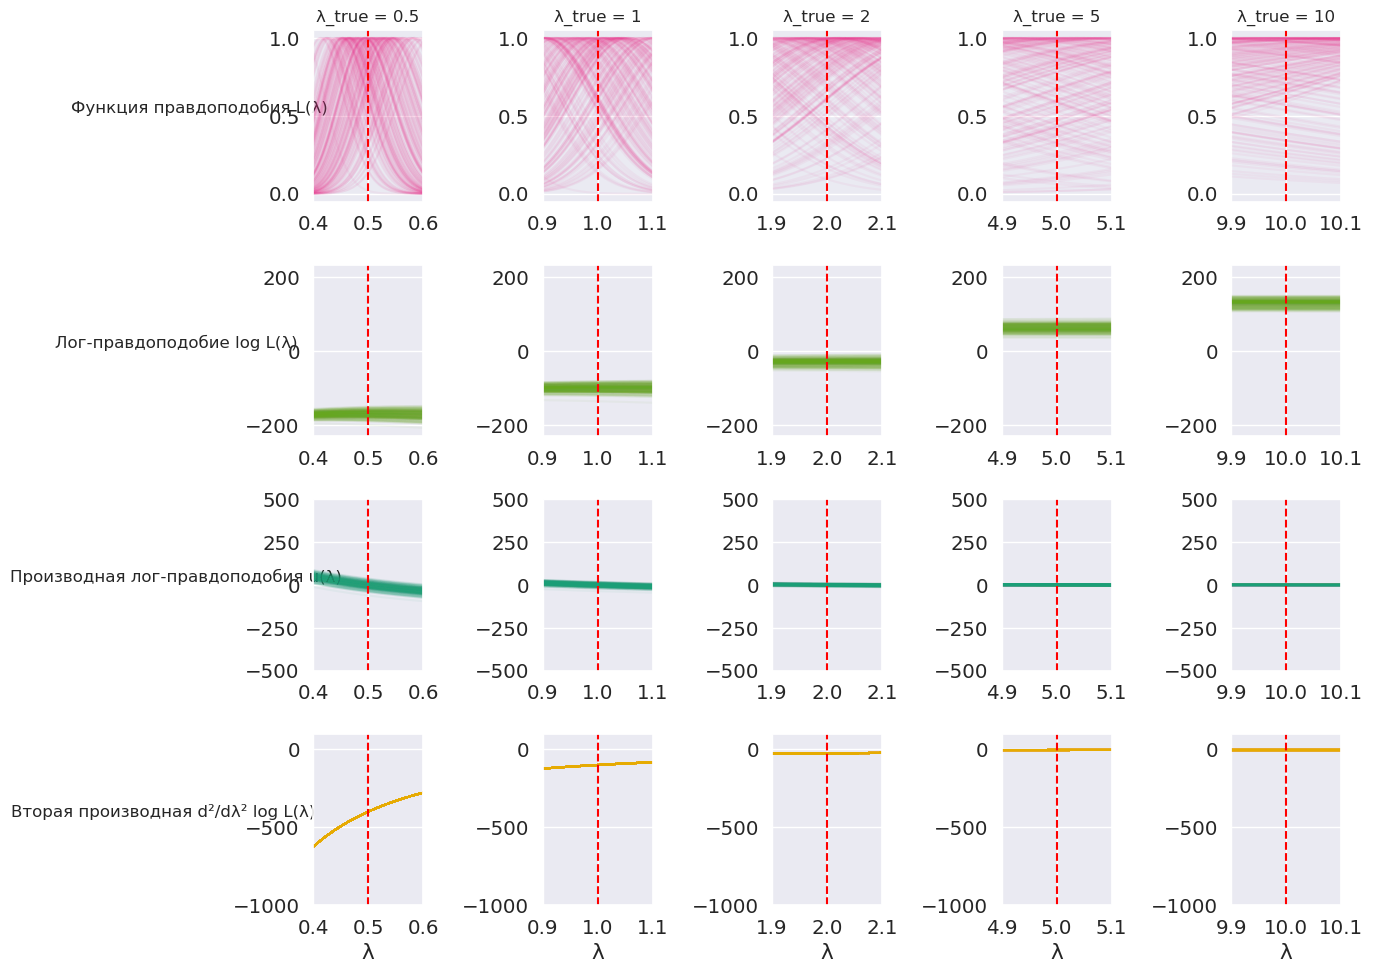

In [263]:
theta_grid = [0.5, 1, 2, 5, 10]
lam = np.linspace(1e-4, max(theta_grid) + 0.3, 10000)[1:-1]
n = 100
k = 200

fig, axes = plt.subplots(
    nrows=4,
    ncols=len(theta_grid),
    figsize=(14, 10),
)

row_names = [
    "Функция правдоподобия L(λ)",
    "Лог-правдоподобие log L(λ)",
    "Производная лог-правдоподобия u(λ)",
    "Вторая производная d²/dλ² log L(λ)"
]

for j, theta in enumerate(theta_grid):
    axes[0, j].set_title(f"λ_true = {theta}", fontsize=12)

for i, name in enumerate(row_names):
    axes[i, 0].set_ylabel(name, fontsize=12, rotation=0, labelpad=50)

for j, theta in tqdm(enumerate(theta_grid), total=len(theta_grid)):
    for t in range(k):
        x = sps.expon(scale=1.0/theta).rvs(size=n)
        T = np.sum(x)

        logL = n * np.log(lam) - lam * T
        logL_max = np.max(logL)
        L_norm = np.exp(logL - logL_max)
        u = n / lam - T
        d2 = - n / (lam ** 2)

        axes[0, j].set_ylim(-0.05, 1.05)
        axes[0, j].plot(lam, L_norm, color='C1', alpha=0.05)

        axes[1, j].set_ylim(n * np.log(0.1), n * np.log(max(theta_grid) + 0.3))
        axes[1, j].plot(lam, logL, color='C2', alpha=0.05)

        axes[2, j].set_ylim(-5 * n, 5 * n)
        axes[2, j].plot(lam, u, color='C3', alpha=0.05)

        axes[3, j].set_ylim(-1e3, 0.1e3)
        axes[3, j].plot(lam, d2, color='C4', alpha=0.05)

    delta = 0.1
    x0 = max(1e-6, theta - delta)
    x1 = theta + delta
    for i in range(4):
        axes[i, j].set_xlim(x0, x1)

    for i in range(4):
        axes[i, j].axvline(theta, linestyle='--', color='r')

for ax in axes[-1]:
    ax.set_xlabel("λ")

plt.tight_layout()
plt.show()


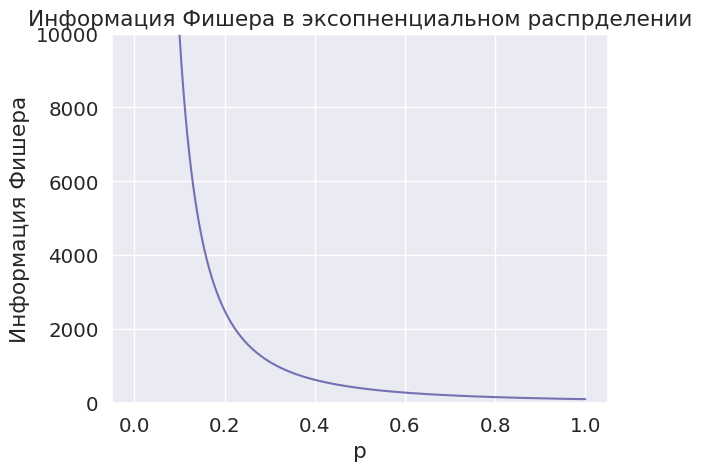

In [261]:
p = np.linspace(0, 1, 10000)[1: -1]
n = 100
I = n / p ** 2

plt.plot(p, I)
plt.title('Информация Фишера в эксопненциальном распрделении')
plt.xlabel('p')
plt.ylabel('Информация Фишера')
plt.ylim(-0.1e2, 1e4)
plt.show()

In [265]:
n = 100
theta_grid = [0.5, 1, 2, 5, 10]
eps = 0.005
lr = 0.01
m = 10_000
lim = 1_000_000

p0s = []
steps = np.zeros((len(theta_grid), m), dtype=int)

for t, theta in enumerate(tqdm(theta_grid)):

    p0 = sps.uniform().rvs(size=m)
    p0s.append(p0)
    lamb = p0.copy()
    
    x = sps.expon(scale=1/theta).rvs(size=(m, n))
    S = x.sum(axis=1)
    mle = n / S

    lamb -= lr * (n / lamb - S)
    steps[t] += 1

    active = np.abs(lamb - mle) > eps

    max_step = 1
    while np.any(active) and max_step < lim:
        lamb[active] -= lr * (n / lamb[active] - S[active])
        steps[t, active] += 1
        max_step += 1
        active = np.abs(lamb - mle) > eps


100%|████████████████████████████████████████████| 5/5 [12:13<00:00, 146.65s/it]


In [266]:
steps_mean = np.mean(steps, axis=1)
print(f'Среднее значение количества шагов прим параметре p = {theta_grid[0]}: {steps_mean[0]:.0f}')
print(f'Среднее значение количества шагов прим параметре p = {theta_grid[1]}: {steps_mean[1]:.0f}')
print(f'Среднее значение количества шагов прим параметре p = {theta_grid[2]}: {steps_mean[2]:.0f}')
print(f'Среднее значение количества шагов прим параметре p = {theta_grid[3]}: {steps_mean[3]:.0f}')

Среднее значение количества шагов прим параметре p = 0.5: 996000
Среднее значение количества шагов прим параметре p = 1: 994400
Среднее значение количества шагов прим параметре p = 2: 996000
Среднее значение количества шагов прим параметре p = 5: 997892


Сделайте выводы

Для непрерывного распрделения разницы в количестве шагов до достижения оптимума практически нет, скорее всего, потому что информация Фишера для выбранных значений параметра практически не меняется.

В отношении остальных пунктов выводы аналогичны

---
© 2025 команда <a href="https://thetahat.ru/">ThetaHat</a> для DS-потока